# Plane Boarding Simulator Demo

This notebook demonstrates how to:

1. Import and configure the plane boarding simulator
2. Run a single simulation for one boarding strategy
3. Compare multiple strategies using total boarding time
4. View congestion over time
5. Display an animated GIF of the boarding process


In [34]:
!rm -rf ../results/*
import os
import sys
import statistics
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import Image, display

### DO NOT EDIT BELOW THIS LINE ###
cwd = os.getcwd()
if os.path.basename(cwd) == "examples":
    repo_root = os.path.dirname(cwd)
else:
    repo_root = cwd

repo_root = Path(repo_root).resolve()
src_path = repo_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from simulation import SimConfig, run_once
from basic_strategies import STRATEGIES

back_to_front, front_to_back, steffen, wilma = (
    STRATEGIES["back_to_front"],
    STRATEGIES["front_to_back"],
    STRATEGIES["steffen"],
    STRATEGIES["wilma"],
)

## Running a Single Simulation


In [35]:
cfg = SimConfig()
cfg.num_rows = 30
cfg.num_passengers = 180
cfg.seed = 42  # for reproducibility

metrics, plane, passengers = run_once(
    cfg,
    boarding_strategy=wilma,
    animate=False,  # set True to print ASCII frames in the notebook output
    save_frames=True,  # saves frames under results/
    perfect_queue=True,  # deterministic ordering
    auto_make_gif=False,  # we will call the GIF function separately below if we want
)

print(f"Strategy: {wilma.name}")
print(f"Total ticks: {metrics.total_ticks}")
print(f"Passengers seated: {metrics.seated_count}")
print(f"Number of congestion samples: {len(metrics.congestion_ts)}")

Strategy: wilma
Total ticks: 535
Passengers seated: 180
Number of congestion samples: 535


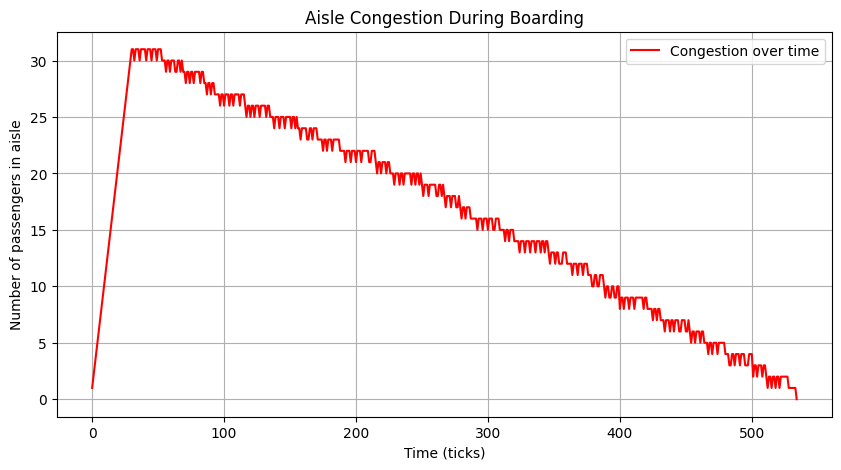

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(metrics.congestion_ts, label="Congestion over time", c="r")
plt.xlabel("Time (ticks)")
plt.ylabel("Number of passengers in aisle")
plt.title("Aisle Congestion During Boarding")
plt.legend()
plt.grid()
plt.show()

## Comparison of 2 Methods over 10 Runs


In [37]:
def run_many(strategy, n_runs=10, num_rows=30, num_passengers=180):
    totals = []
    for i in range(n_runs):
        cfg = SimConfig()
        cfg.num_rows = num_rows
        cfg.num_passengers = num_passengers
        cfg.seed = i  # different seed each run

        metrics, plane, passengers = run_once(
            cfg,
            boarding_strategy=strategy,
            animate=False,
            save_frames=False,
            perfect_queue=False,  # allow randomness in the queue
        )
        totals.append(metrics.total_ticks)
    return totals


strategies = {
    "back_to_front": back_to_front,
    "front_to_back": front_to_back,
}

results = {}
for name, strat in strategies.items():
    totals = run_many(strat, n_runs=10)
    results[name] = totals
    print(
        f"{name}: mean={statistics.mean(totals):.1f}, stdev={statistics.pstdev(totals):.1f}"
    )

back_to_front: mean=516.8, stdev=15.7
front_to_back: mean=650.4, stdev=21.9


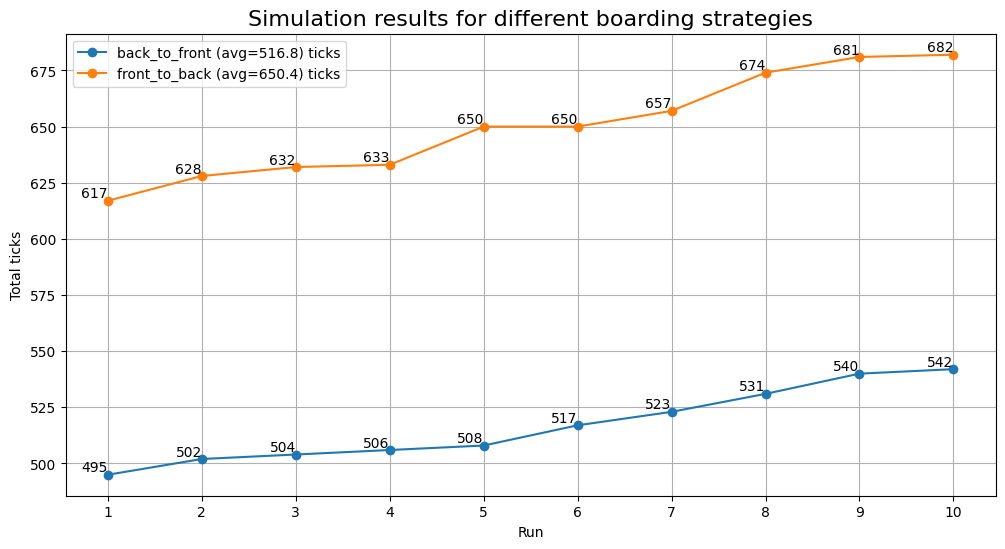

In [38]:
plt.figure(figsize=(12, 6))
for name, totals in results.items():
    plt.plot(
        range(1, len(totals) + 1),
        sorted(totals),
        marker="o",
        label=f"{name} (avg={statistics.mean(totals):.1f}) ticks",
    )

    # Value for each marker
    for i, total in enumerate(sorted(totals), start=1):
        plt.text(i, total, str(total), fontsize=10, ha="right", va="bottom")

plt.xticks(range(1, 11))
plt.xlabel("Run")
plt.ylabel("Total ticks")
plt.title("Simulation results for different boarding strategies", fontdict={"size": 16})
plt.legend()
plt.grid(True)
plt.show()

## Animated Results from a Single Run


In [39]:
cfg = SimConfig()
cfg.num_rows = 30
cfg.num_passengers = cfg.num_rows * 6
cfg.seed = 42

metrics, plane, passengers = run_once(
    cfg,
    boarding_strategy=steffen,
    animate=False,  # set True to print ASCII frames in the notebook output
    save_frames=True,  # saves frames under results/
    perfect_queue=True,  # deterministic ordering
    auto_make_gif=True,  # automatically create GIF from saved frames
)

print(f"Strategy: {steffen.name}")
print(f"Total ticks: {metrics.total_ticks}")
print(f"Passengers seated: {metrics.seated_count}")
print(f"Number of congestion samples: {len(metrics.congestion_ts)}")

Wrote GIF to /home/manpazito/projects/class-materials/IEOR 174/plane-boarding-sim/results/steffen_1764732748/steffen_animation.gif (frames: 579)
Strategy: steffen
Total ticks: 579
Passengers seated: 180
Number of congestion samples: 579


### Displaying the Output GIF


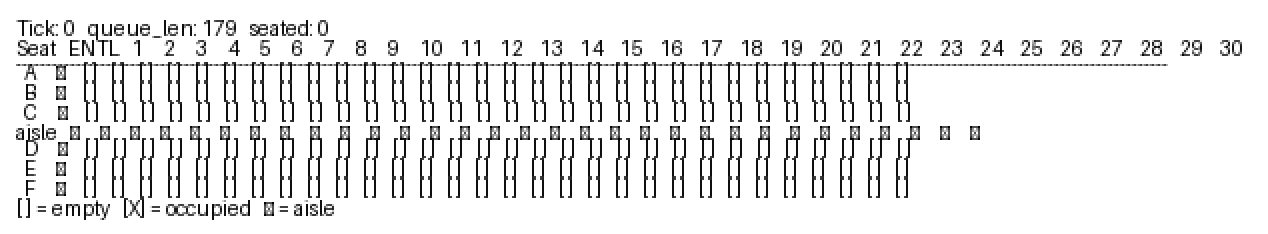

In [40]:
results_path = repo_root / "results"

if str(results_path) not in sys.path:
    sys.path.insert(0, str(results_path))

results_outputs = os.listdir(results_path)
most_recent_steffen = [f for f in results_outputs if f.startswith("steffen")][-1]
gif_path = results_path / most_recent_steffen / "steffen_animation.gif"


display(Image(filename=gif_path))

## Passenger Analytics


In [41]:
import pandas as pd

passenger_path = results_path / most_recent_steffen / "steffen_passengers.csv"
passengers = pd.read_csv(passenger_path)
passengers.head()

,pid,target_row,target_letter,missed,entry_time,seat_time,time_to_seat,has_bag,walk_ticks,stow_ticks,lane,entry_door
0,3,2,A,False,0,2,2,False,1,NaN,0,front
1,14,2,B,False,1,6,5,True,1,2.0,0,front
2,13,2,C,False,2,10,8,True,1,2.0,0,front
3,78,2,D,False,3,13,10,True,1,1.0,0,front
4,58,2,E,False,7,16,9,True,1,1.0,0,front


### Let's look at when passengers arrived.


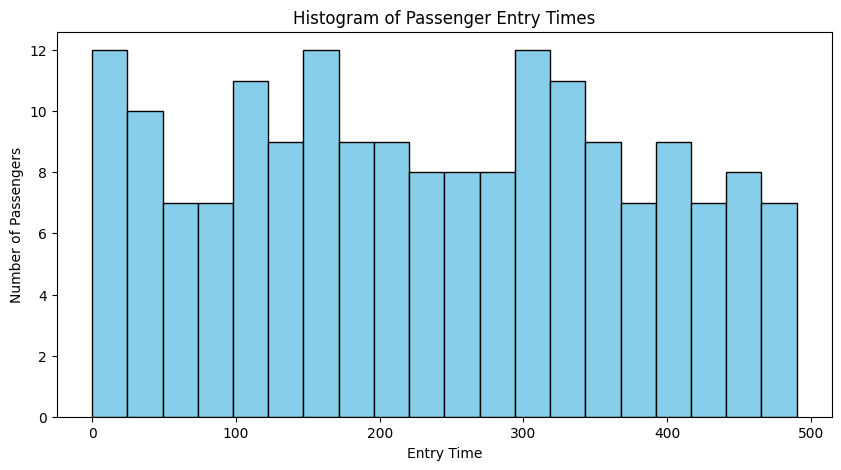

In [42]:
plt.figure(figsize=(10, 5))
plt.hist(passengers["entry_time"], bins=20, color="skyblue", edgecolor="black")
plt.xlabel("Entry Time")
plt.ylabel("Number of Passengers")
plt.title("Histogram of Passenger Entry Times")
plt.show()

### How about the amount of time it took people to stow and sit down?


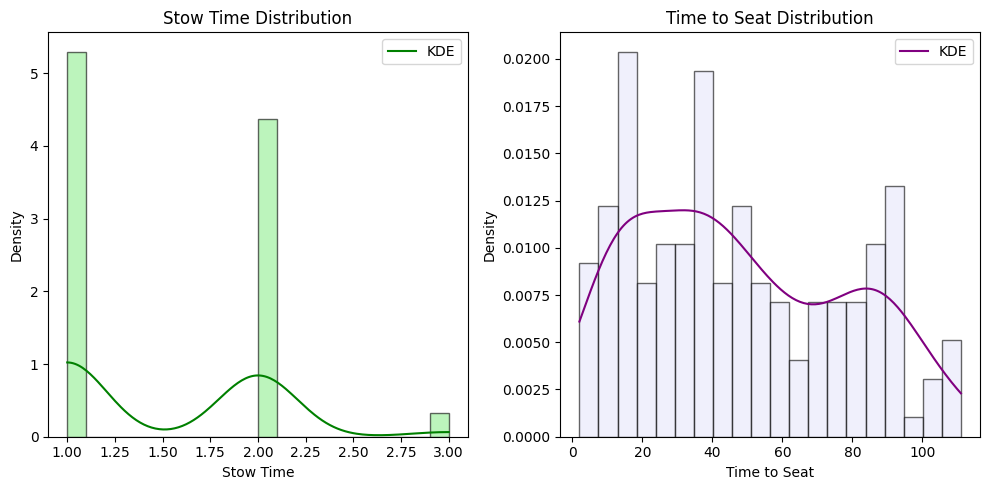

In [43]:
from scipy import stats
import numpy as np

plt.figure(figsize=(10, 5))

# Histogram + KDE for stow_ticks
plt.subplot(1, 2, 1)
data = passengers["stow_ticks"].dropna()
plt.hist(data, bins=20, color="lightgreen", edgecolor="black", density=True, alpha=0.6)
kde = stats.gaussian_kde(data)
x_vals = np.linspace(data.min(), data.max(), 200)
plt.plot(x_vals, kde(x_vals), color="green", label="KDE")
plt.legend()
plt.xlabel("Stow Time")
plt.ylabel("Density")
plt.title("Stow Time Distribution")

# Histogram + KDE for time_to_seat
plt.subplot(1, 2, 2)
data2 = passengers["time_to_seat"].dropna()
plt.hist(data2, bins=20, color="lavender", edgecolor="black", density=True, alpha=0.6)
kde2 = stats.gaussian_kde(data2)
x2 = np.linspace(data2.min(), data2.max(), 200)
plt.plot(x2, kde2(x2), color="purple", label="KDE")
plt.legend()
plt.xlabel("Time to Seat")
plt.ylabel("Density")
plt.title("Time to Seat Distribution")
plt.tight_layout()
plt.show()

### Did any passengers miss their seats?


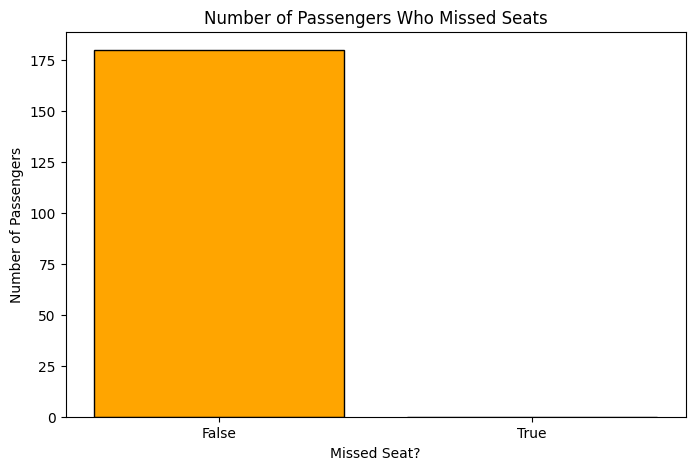

In [44]:
counts = passengers["missed"].value_counts().reindex([False, True], fill_value=0)

plt.figure(figsize=(8, 5))
plt.bar(["False", "True"], counts, color="orange", edgecolor="black")
plt.xlabel("Missed Seat?")
plt.ylabel("Number of Passengers")
plt.title("Number of Passengers Who Missed Seats")
plt.show()